# Damkohler--Peclet Regimes and RTZ Admissibility

This notebook maps a user-defined scaffold state onto the Damkohler--Peclet plane and evaluates its full chemistry trajectory against the three-phase regenerative target zone (RTZ).

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from kineticai import da_pe_from_state, phase_trajectory_distance, admissible_tube

architecture = {'beta0': 10.0, 'length': 0.10, 'velocity': 0.10, 'D_eff': 0.010}
chemistry = {'alpha': 0.80, 'k_diss': 0.50, 'C0': 1.0}
da, pe = da_pe_from_state(chemistry['alpha'], chemistry['k_diss'], architecture['beta0'], architecture['length'], architecture['D_eff'], architecture['velocity'])
print(f'Da = {da:.3f}, Pe = {pe:.3f}')

Da = 4.000, Pe = 1.000


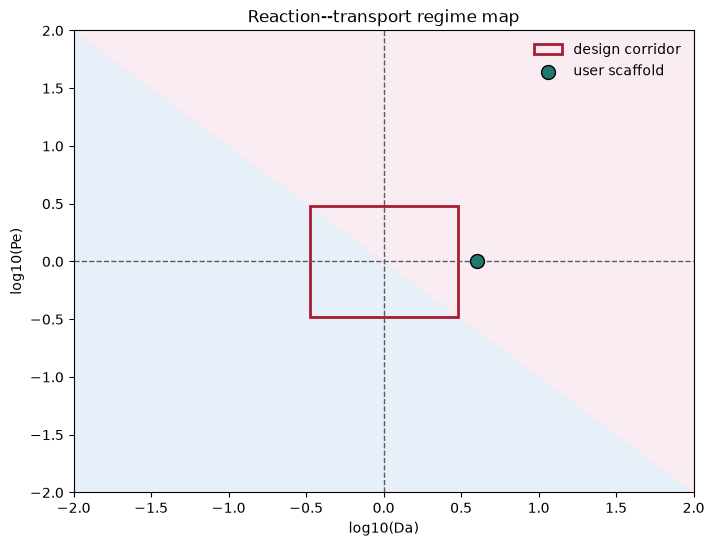

In [2]:
log_da = np.linspace(-2, 2, 240)
log_pe = np.linspace(-2, 2, 240)
DA, PE = np.meshgrid(log_da, log_pe)
fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(DA, PE, DA + PE, levels=[-4, 0, 4], colors=['#dfeaf7', '#f7e8ef'], alpha=0.75)
ax.axvline(0, color='0.35', linestyle='--', linewidth=1)
ax.axhline(0, color='0.35', linestyle='--', linewidth=1)
ax.add_patch(plt.Rectangle((-np.log10(3), -np.log10(3)), 2*np.log10(3), 2*np.log10(3), fill=False, edgecolor='#a91d33', linewidth=2, label='design corridor'))
ax.scatter(np.log10(da), np.log10(pe), s=100, color='#1d7a6d', edgecolor='black', zorder=4, label='user scaffold')
ax.set_xlabel('log10(Da)')
ax.set_ylabel('log10(Pe)')
ax.set_title('Reaction--transport regime map')
ax.legend(frameon=False)
plt.show()

## Phase-scheduled RTZ tube

The state vector is `[Ca, Si, Mg, pH, porosity]`. Bounds are normalized for the demonstration and are applied continuously across Phase I (0--48 h), Phase II (D3--D7), and Phase III (>D14).

RTZ distance = 0.000000; biologically admissible = True


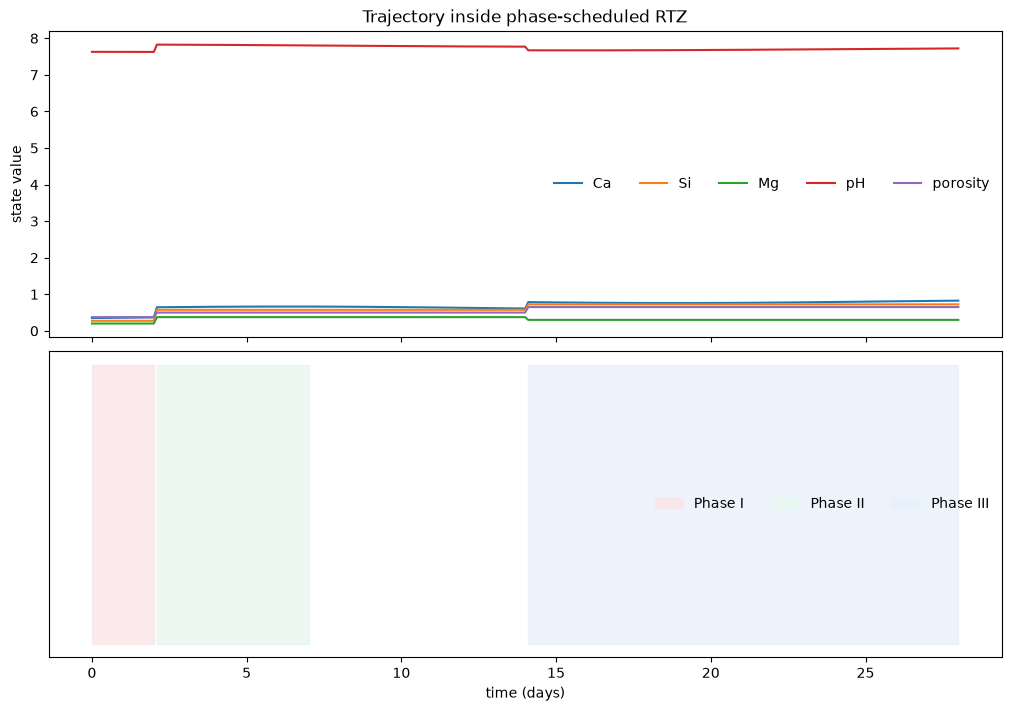

In [3]:
time = np.linspace(0, 28, 281)
phase1 = time <= 2
phase2 = (time > 2) & (time <= 7)
phase3 = time > 14
lower = np.zeros((len(time), 5)); upper = np.zeros((len(time), 5))
bounds = {
    'p1': (np.array([0.15, 0.10, 0.05, 7.35, 0.20]), np.array([0.55, 0.45, 0.35, 7.85, 0.55])),
    'p2': (np.array([0.35, 0.30, 0.15, 7.40, 0.30]), np.array([0.90, 0.85, 0.60, 8.20, 0.70])),
    'p3': (np.array([0.50, 0.45, 0.10, 7.40, 0.45]), np.array([1.10, 1.00, 0.50, 8.00, 0.85])),
}
for mask, key in [(phase1, 'p1'), (phase2, 'p2'), (phase3, 'p3')]:
    lower[mask], upper[mask] = bounds[key]
unassigned = ~(phase1 | phase2 | phase3)
lower[unassigned], upper[unassigned] = bounds['p2']
trajectory = (lower + upper) / 2
trajectory[:, 0] += 0.04 * np.sin(time / 4)
trajectory[:, 3] += 0.03 * np.cos(time / 5)
distance = phase_trajectory_distance(trajectory, lower, upper)
admissible = admissible_tube(trajectory, lower, upper)
print(f'RTZ distance = {distance:.6f}; biologically admissible = {admissible}')

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
for j, label in enumerate(['Ca', 'Si', 'Mg', 'pH', 'porosity']):
    axes[0].plot(time, trajectory[:, j], label=label)
axes[0].set_ylabel('state value')
axes[0].legend(ncol=5, frameon=False)
axes[0].set_title('Trajectory inside phase-scheduled RTZ')
axes[1].fill_between(time, 0, 1, where=phase1, color='#fbe5e7', alpha=0.8, label='Phase I')
axes[1].fill_between(time, 0, 1, where=phase2, color='#e8f7ef', alpha=0.8, label='Phase II')
axes[1].fill_between(time, 0, 1, where=phase3, color='#e8f0fb', alpha=0.8, label='Phase III')
axes[1].set_yticks([]); axes[1].set_xlabel('time (days)')
axes[1].legend(frameon=False, ncol=3)
plt.show()